In [22]:
import numpy as np
import bdms
import pandas as pd

In [23]:
birth = bdms.poisson.DiscreteProcess([1.0, 2.0])
death = bdms.poisson.ConstantProcess(1.0)
mutation = bdms.poisson.ConstantProcess(1.0)
mutator = bdms.mutators.DiscreteMutator((0, 1), np.array([[0, 1], [1, 0]]))

In [24]:
rng = np.random.default_rng(seed=0)

In [25]:
tree = bdms.Tree(state=0)

In [26]:
time_to_sampling = 5.0

tree.evolve(
    time_to_sampling,
    birth_process=birth,
    death_process=death,
    mutation_process=mutation,
    mutator=mutator,
    seed=rng,
)

In [27]:
tree

Tree node '0' (0x77f19c4b352)

In [28]:
tree.sample_survivors(p=0.5, seed=rng)

In [29]:
viz_kwargs = dict(
    color_map={0: "red", 1: "blue"},
    h=5,
    units="in",
)

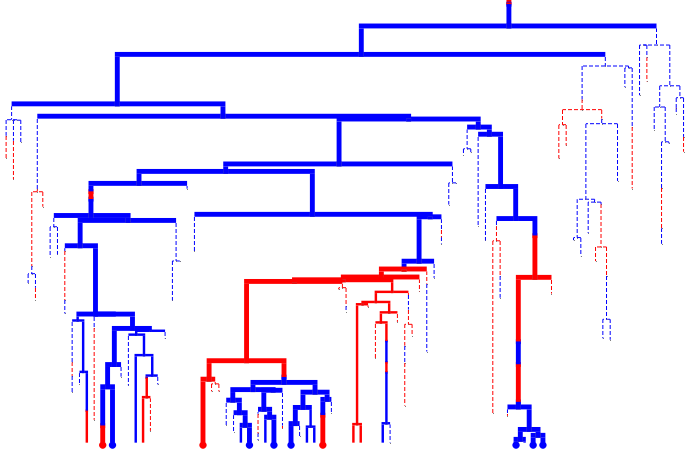

In [30]:
tree.render("%%inline", **viz_kwargs)

In [31]:
# Example operations
for node in tree.traverse():
    if node.is_leaf():
        print(f"Leaf: {node.name}, dist to parent: {node.dist}")
    else:
        print(f"Internal node: {node.name}, dist to parent: {node.dist}")

Internal node: 0, dist to parent: 0.0
Internal node: 1, dist to parent: 0.019806662589055352
Internal node: 2, dist to parent: 0.2751714363195241
Internal node: 3, dist to parent: 0.18882533945634783
Internal node: 4, dist to parent: 0.3227150022830663
Internal node: 5, dist to parent: 0.462789928351992
Internal node: 6, dist to parent: 0.00021462505580382985
Internal node: 9, dist to parent: 0.1042193670037872
Internal node: 10, dist to parent: 0.5619059944076208
Internal node: 16, dist to parent: 0.13512308044486376
Internal node: 17, dist to parent: 0.24107449298453743
Internal node: 7, dist to parent: 0.14107587752805223
Leaf: 8, dist to parent: 0.5697441046685001
Internal node: 12, dist to parent: 0.021076142087829153
Internal node: 13, dist to parent: 0.3805629846500582
Internal node: 21, dist to parent: 0.14032646422300443
Internal node: 22, dist to parent: 0.15271133137044623
Internal node: 18, dist to parent: 0.4449962387270281
Internal node: 19, dist to parent: 0.116333869120

In [32]:
# Step 1: Collect all nodes and assign unique indices
node_list = list(tree.traverse("preorder"))
node_to_idx = {node: i for i, node in enumerate(node_list)}
idx_to_node = {i: node for node, i in node_to_idx.items()}

# Optional: create readable node names
node_names = []
for node in node_list:
    if node.name:
        node_names.append(node.name)
    else:
        node_names.append(f"node_{node_to_idx[node]}")

# Step 2: Build adjacency matrix (binary or weighted)
N = len(node_list)
adj = np.zeros((N, N), dtype=int)

for node in node_list:
    for child in node.children:
        i = node_to_idx[node]
        j = node_to_idx[child]
        adj[i, j] = 1
        adj[j, i] = 1  # Undirected

# Step 3: Build distance matrix using LCA distances
dist = np.zeros((N, N), dtype=float)

for i in range(N):
    for j in range(i + 1, N):
        ni, nj = idx_to_node[i], idx_to_node[j]
        lca = tree.get_common_ancestor(ni, nj)
        d = ni.get_distance(lca) + nj.get_distance(lca)
        dist[i, j] = d
        dist[j, i] = d  # Symmetric


In [33]:
adj_df = pd.DataFrame(adj, index=node_names, columns=node_names)
dist_df = pd.DataFrame(dist, index=node_names, columns=node_names)

In [34]:
adj_df

,node_0,1,2,3,5,16,18,48,19,25,...,109,124,110,22,32,34,35,49,33,45
node_0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
35,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
49,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
33,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [35]:
dist_df

,node_0,1,2,3,5,16,18,48,19,25,...,109,124,110,22,32,34,35,49,33,45
node_0,0.000000,0.019807,0.294978,0.483803,0.946593,1.081716,1.526713,1.695571,1.198050,1.204075,...,3.241060,3.374020,3.186799,1.332310,1.337536,1.589283,1.570726,2.007585,1.514641,1.771839
1,0.019807,0.000000,0.275171,0.463997,0.926787,1.061910,1.506906,1.675764,1.178244,1.184268,...,3.221253,3.354213,3.166993,1.312504,1.317729,1.569477,1.550919,1.987779,1.494834,1.752032
2,0.294978,0.275171,0.000000,0.188825,0.651615,0.786738,1.231735,1.400593,0.903072,0.909097,...,2.946081,3.079042,2.891821,1.037332,1.042558,1.294305,1.275748,1.712607,1.219663,1.476861
3,0.483803,0.463997,0.188825,0.000000,0.462790,0.597913,1.042909,1.211768,0.714247,0.720272,...,3.134907,3.267867,3.080647,1.226158,1.231383,1.483131,1.464573,1.901433,1.408488,1.665686
5,0.946593,0.926787,0.651615,0.462790,0.000000,0.135123,0.580119,0.748978,0.251457,0.257482,...,3.597697,3.730657,3.543436,1.688948,1.694173,1.945921,1.927363,2.364223,1.871278,2.128476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,1.589283,1.569477,1.294305,1.483131,1.945921,2.081044,2.526040,2.694898,2.197378,2.203402,...,2.471145,2.604105,2.416885,0.256973,0.251748,0.000000,0.484938,0.921797,0.439303,0.696502
35,1.570726,1.550919,1.275748,1.464573,1.927363,2.062486,2.507482,2.676341,2.178820,2.184844,...,2.452587,2.585547,2.398327,0.238415,0.233190,0.484938,0.000000,0.436860,0.420746,0.677944
49,2.007585,1.987779,1.712607,1.901433,2.364223,2.499346,2.944342,3.113200,2.615680,2.621704,...,2.889447,3.022407,2.835187,0.675275,0.670050,0.921797,0.436860,0.000000,0.857606,1.114804
33,1.514641,1.494834,1.219663,1.408488,1.871278,2.006401,2.451397,2.620256,2.122735,2.128760,...,2.396502,2.529463,2.342242,0.182330,0.187556,0.439303,0.420746,0.857606,0.000000,0.257198


In [36]:
for i, node in enumerate(tree.traverse("preorder")):
    if i >= 2:
        break
    print(f"\nNode {i} — ID: {id(node)}")
    print(f"  Name    : {node.name}")
    print(f"  Distance: {node.dist}")
    print(f"  Support : {getattr(node, 'support', None)}")
    
    # Print explicitly added features
    if node.features:
        print(f"  Features:")
        for feat in node.features:
            print(f"    {feat}: {getattr(node, feat)}")

    # Custom attributes that aren't part of ETE internals
    custom_attrs = set(vars(node).keys()) - set(dir(type(node)))
    for attr in custom_attrs:
        print(f"Custom Attr - {attr}: {getattr(node, attr)}")

    # Show children briefly
    print(f"  #Children: {len(node.children)}")
    print(f"  Leaf     : {node.is_leaf()}")


Node 0 — ID: 131879592998176
  Name    : 0
  Distance: 0.0
  Support : 1.0
  Features:
    support: 1.0
    _nid: 0
    dist: 0.0
    name: 0
Custom Attr - _temp_faces: None
Custom Attr - _sampled: True
Custom Attr - _up: None
Custom Attr - _img_style: {'fgcolor': 'red', 'bgcolor': '#FFFFFF', 'vt_line_color': 'red', 'hz_line_color': '#000000', 'hz_line_type': 0, 'vt_line_type': 0, 'size': 0, 'shape': 'circle', 'draw_descendants': True, 'hz_line_width': 2, 'vt_line_width': 2}
Custom Attr - _nid: 0
Custom Attr - _dist: 0.0
Custom Attr - _support: 1.0
Custom Attr - state_attr: state
Custom Attr - _children: [Tree node '1' (0x77f19c4b311)]
Custom Attr - n_mutations: 0
Custom Attr - t: 0
Custom Attr - _faces: <ete3.treeview.main._FaceAreas object at 0x77f19c4e70d0>
Custom Attr - features: {'support', '_nid', 'dist', 'name'}
Custom Attr - name: 0
Custom Attr - state: 0
Custom Attr - event: None
Custom Attr - _pruned: False
Custom Attr - _mutations_removed: False
  #Children: 1
  Leaf     : 

In [42]:
tree.prune_unsampled()

ValueError: tree has already been pruned below node 0

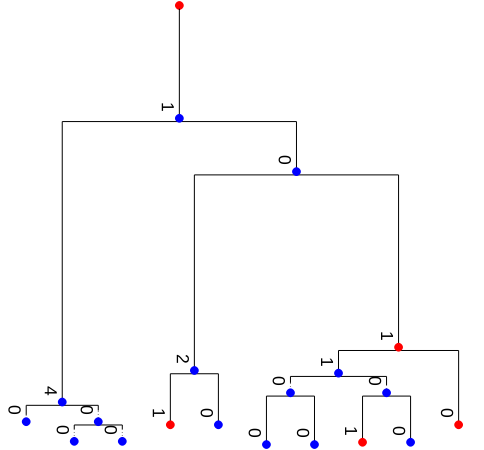

In [43]:
tree.render("%%inline", **viz_kwargs)

In [44]:
tree.remove_mutation_events()

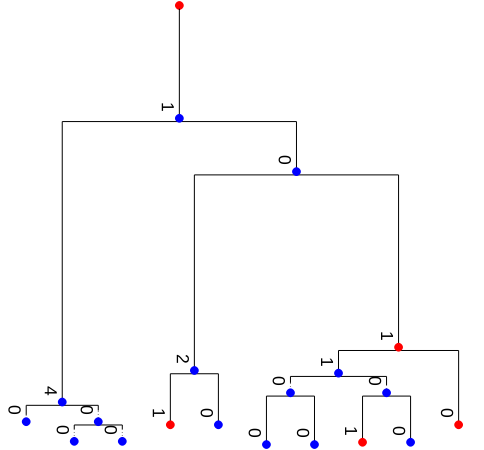

In [45]:
tree.render("%%inline", **viz_kwargs)